In [16]:
import torch
import torchvision.transforms as T
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [17]:
VOC_COLORS = np.array([
    (0, 0, 0),        # background
    (128, 0, 0),      # aeroplane
    (0, 128, 0),      # bicycle
    (128, 128, 0),    # bird
    (0, 0, 128),      # boat
    (128, 0, 128),    # bottle
    (0, 128, 128),    # bus
    (128, 128, 128),  # car
    (64, 0, 0),       # cat
    (192, 0, 0),      # chair
    (64, 128, 0),     # cow
    (192, 128, 0),    # dining table
    (64, 0, 128),     # dog
    (192, 0, 128),    # horse
    (64, 128, 128),   # motorbike
    (192, 128, 128),  # person
    (0, 64, 0),       # potted plant
    (128, 64, 0),     # sheep
    (0, 192, 0),      # sofa
    (128, 192, 0),    # train
    (0, 64, 128),     # tv/monitor
], dtype=np.uint8)

In [18]:
def decode_segmap(segmentation):
    r = np.zeros_like(segmentation).astype(np.uint8)
    g = np.zeros_like(segmentation).astype(np.uint8)
    b = np.zeros_like(segmentation).astype(np.uint8)

    for l in range(0, VOC_COLORS.shape[0]):
        mask = segmentation == l
        r[mask] = VOC_COLORS[l, 0]
        g[mask] = VOC_COLORS[l, 1]
        b[mask] = VOC_COLORS[l, 2]

    rgb = np.stack([r, g, b], axis=2)
    return rgb

In [19]:
image_path = 'obj.png'
image = Image.open(image_path).convert('RGB')


transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(image).unsqueeze(0)  #for batch conv

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models_dict = {
    'FCN-32s': models.segmentation.fcn_resnet50(pretrained=True, progress=True),
    'FCN-16s': models.segmentation.fcn_resnet101(pretrained=True, progress=True),
    'FCN-8s': models.segmentation.deeplabv3_resnet50(pretrained=True, progress=True),
}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet101_Weights.DE

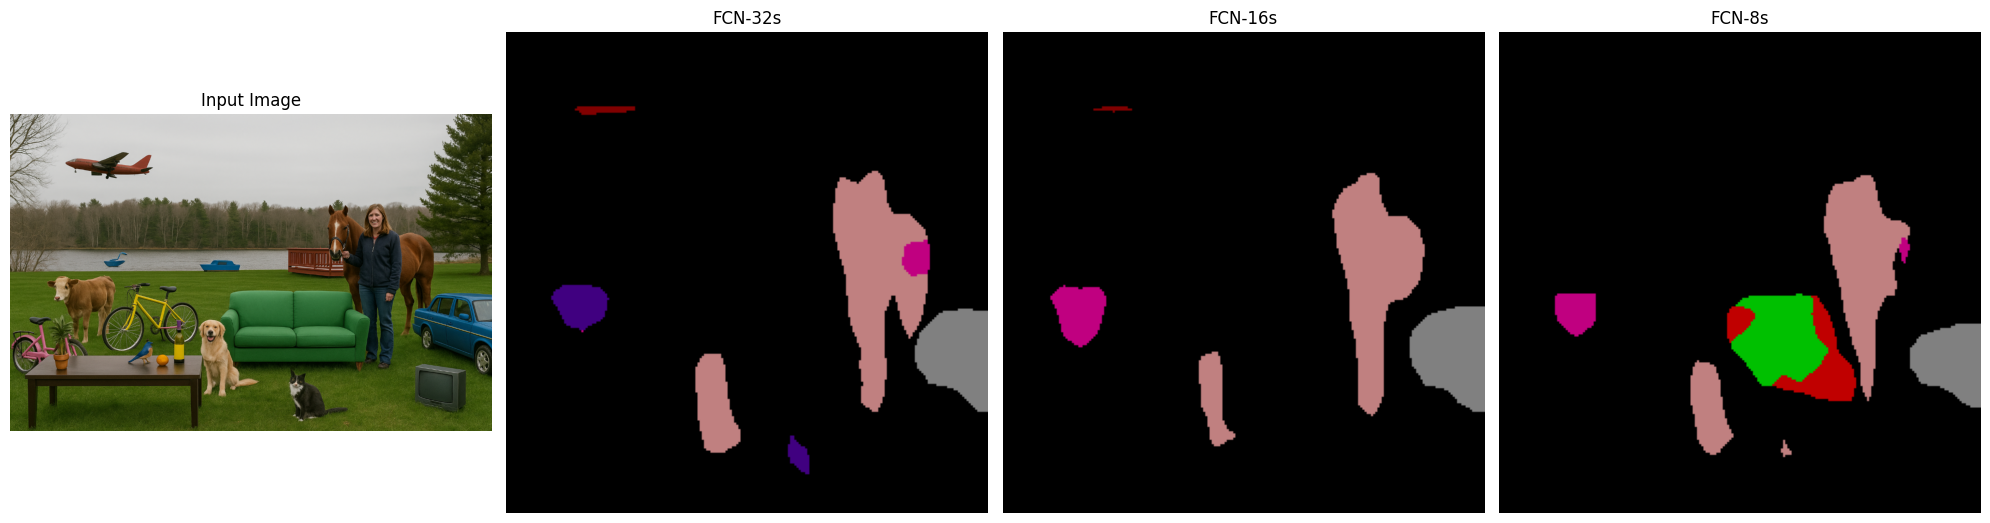

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(image)
axes[0].set_title("Input Image")
axes[0].axis('off')

for idx, (name, model) in enumerate(models_dict.items()):
    model = model.eval().to(device)
    with torch.no_grad():
        output = model(input_tensor.to(device))['out'][0]
        pred = output.argmax(0).cpu().numpy()

    color_seg = decode_segmap(pred)
    axes[idx + 1].imshow(color_seg)
    axes[idx + 1].set_title(name)
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()